In [91]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [92]:
iris_dataset = load_iris()
iris_dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [93]:
print(iris_dataset.feature_names)
print(iris_dataset.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [94]:
X = pd.DataFrame(data=iris_dataset.data,columns=iris_dataset.feature_names)
y = pd.Series(data=iris_dataset.target,name='Target')

df = X.copy()
df['target'] = y

df.shape

(150, 5)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [96]:
df.describe(include='all')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [97]:
# Data Split :
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [98]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
gnb = GaussianNB()

In [100]:
gnb.fit(X_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [101]:
y_train_pred = gnb.predict(X_train_scaled)
y_test_pred = gnb.predict(X_test_scaled)

In [102]:
print(f"Accuracy Train : {accuracy_score(y_train,y_train_pred)}")
print(f"Accuracy Test : {accuracy_score(y_test,y_test_pred)}")

Accuracy Train : 0.9583333333333334
Accuracy Test : 0.9666666666666667


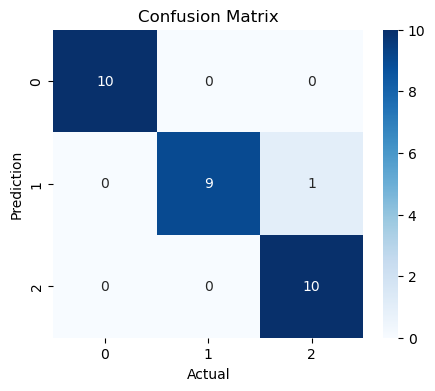

In [103]:
cm = confusion_matrix(y_test,y_test_pred)

plt.figure(figsize=(5,4))
plt.title("Confusion Matrix")
sns.heatmap(data=cm,fmt='d',annot=True,cmap='Blues')
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.show()

In [104]:
print(classification_report(y_test,y_test_pred,target_names=iris_dataset.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [105]:
cv_scores = cross_val_score(gnb,X,y,cv=5,scoring='accuracy')
print(f"Accuracy Score across (k fold=5) : {cv_scores.mean()}")

Accuracy Score across (k fold=5) : 0.9533333333333334


### Prediction On Sample

In [106]:
# Ask user to give his data 
sample = {
            'sepal length (cm)' : [],
            'sepal width (cm)' : [],
            'petal length (cm)' : [],
            'petal width (cm)' : []
        }
for col in sample.keys():
    val = float(input(f'Enter {col} : '))
    sample[col].append(val)
    
sample_df = pd.DataFrame(sample)
sample_df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2


In [108]:
sample_scaled = scaler.transform(sample_df)
print(sample_scaled)

print(f"Predicted Species : {iris_dataset.target_names[int(gnb.predict(sample_scaled)[0])].capitalize()}")

[[-0.88566202  1.01122923 -1.34572231 -1.32327558]]
Predicted Species : Setosa
